# 02 · Modelo 1 — Clustering de candidatos: comparación de 3 representaciones

**Objetivo del TFG:** segmentar el talento (candidatos) y comparar **tres formas de representar el
perfil del candidato** antes de agrupar, eligiendo la mejor por calidad de cluster.

**Representaciones comparadas**
1. **skills_only** — vector binario sobre las skills únicas de los candidatos.
2. **enriquecida** — binaria + experiencia, idiomas (nº y nivel) y nivel educativo (escaladas a [0,1]).
3. **tfidf_text** — TF-IDF del **texto completo del CV** reducido con **TruncatedSVD** (espacio LSA).

Para cada una: selección de K (codo + silhouette, **K=2..8**), K-Means, silhouette del K elegido y
proyección **PCA 2D**. Tabla comparativa final y elección de la **principal** (mejor silhouette).

**Entradas:** `data/clean/*.csv` + `backend/.../cv_ocr_analizados_100.json` (texto del CV).
**Salida:** `data/clean/candidate_clusters.csv` + figuras en `notebooks/figures/`.

## 0. Protocolo y métrica (declarado explícitamente)

- **Métrica del silhouette: COSENO**, la **misma en las tres representaciones** (para que sean
  comparables). Es coherente con vectores de *presencia* de skills (no-negativos) y con el espacio
  **LSA** (TF-IDF+SVD) del texto. K-Means optimiza inercia euclídea (su definición); lo que se
  mantiene constante entre representaciones es la **métrica de evaluación** (coseno).
- **Reproducibilidad:** `random_state=42`, `n_init=10`, **K∈{2,…,8}**.
- **Honestidad (CLAUDE.md):** con 100 candidatos y skills muy compartidas es esperable un silhouette
  bajo. **Si silhouette < 0.2 se reporta como resultado válido** (talento homogéneo), sin forzar interpretación.

In [1]:
import json, unicodedata, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
ACCENT = "#A100FF"
RANDOM_STATE = 42
METRIC = "cosine"          # <-- métrica del silhouette, igual para las 3 representaciones
KRANGE = range(2, 9)       # K = 2..8

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "data" / "clean").exists() or (p / "CLAUDE.md").exists():
            return p
        p = p.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
CLEAN = REPO_ROOT / "data" / "clean"
FIG = REPO_ROOT / "notebooks" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
CV_JSON = REPO_ROOT / "backend" / "app" / "services" / "ocr" / "data" / "cv_ocr_analizados_100.json"

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c)).lower()

print("REPO_ROOT:", REPO_ROOT, "| métrica silhouette:", METRIC, "| K:", list(KRANGE))

REPO_ROOT: C:\Users\miguel.e.fernandez\Desktop\MatchKey-GenAI-Maverick | métrica silhouette: cosine | K: [2, 3, 4, 5, 6, 7, 8]


## 1. Construcción de las 3 representaciones (mismo orden de candidatos)

In [2]:
# --- R1: skills_only (binaria) ---
cs = pd.read_csv(CLEAN / "candidate_skills_clean.csv")
Xb = pd.crosstab(cs["candidate_id"], cs["skill_norm"])
Xb = (Xb > 0).astype(int)
Xb = Xb[Xb.sum(axis=1) > 0]
master_ids = list(Xb.index)          # orden maestro de candidatos (alineamos todo a esto)
skill_names = list(Xb.columns)
R1 = Xb.values.astype(float)
print("R1 skills_only:", R1.shape, "->", len(skill_names), "skills")

# --- R2: enriquecida (binaria + experiencia + idiomas + nivel educativo, escaladas) ---
cc = pd.read_csv(CLEAN / "candidates_clean.csv").set_index("candidate_id")
edu = pd.read_csv(CLEAN.parent / "matchkey" / "candidate_education.csv")
lang = pd.read_csv(CLEAN.parent / "matchkey" / "candidate_languages.csv")

EDU_LEVEL = {"doctor": 3, "master": 2, "grado": 1, "licenciat": 1, "ingenier": 1}
def edu_level(deg):
    d = strip_accents(deg)
    for kw, lv in EDU_LEVEL.items():
        if kw in d:
            return lv
    return 0
edu["lvl"] = edu["degree"].fillna("").map(edu_level)
edu_max = edu.groupby("candidate_id")["lvl"].max()

LANG_LEVEL = {"nativo": 5, "c2": 4, "c1": 3, "b2": 2, "b1": 1}
lang["lvl"] = lang["level"].fillna("").map(lambda x: LANG_LEVEL.get(strip_accents(x), 0))
lang_max = lang.groupby("candidate_id")["lvl"].max()

num = pd.DataFrame(index=master_ids)
num["years_experience"] = cc["years_experience"].reindex(master_ids)
num["n_languages"] = cc["n_languages"].reindex(master_ids)
num["max_lang_level"] = lang_max.reindex(master_ids)
num["education_level"] = edu_max.reindex(master_ids)
num = num.fillna(0)
num_scaled = MinMaxScaler().fit_transform(num.values)   # -> [0,1], cosine sigue no-negativo
R2 = np.hstack([R1, num_scaled])
print("R2 enriquecida:", R2.shape, "(", R1.shape[1], "skills +", num.shape[1], "numéricas:", list(num.columns), ")")

# --- R3: tfidf_text (texto completo del CV) + TruncatedSVD (LSA) ---
cv = json.load(open(CV_JSON, encoding="utf-8"))
raw_by_id = {c["candidate_id"]: (c.get("document_parser", {}) or {}).get("raw_text", "") or "" for c in cv}
docs = [raw_by_id.get(cid, "") for cid in master_ids]
tfidf = TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
T = tfidf.fit_transform(docs)
n_comp = int(min(50, T.shape[1] - 1, len(master_ids) - 1))
svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
R3 = svd.fit_transform(T)
print(f"R3 tfidf_text: TF-IDF {T.shape} -> SVD {R3.shape}  (var. explicada SVD: {svd.explained_variance_ratio_.sum()*100:.1f}%)")

REPS = {"skills_only": R1, "enriquecida": R2, "tfidf_text": R3}

R1 skills_only: (100, 32) -> 32 skills
R2 enriquecida: (100, 36) ( 32 skills + 4 numéricas: ['years_experience', 'n_languages', 'max_lang_level', 'education_level'] )


R3 tfidf_text: TF-IDF (100, 406) -> SVD (100, 50)  (var. explicada SVD: 87.2%)


## 2. Selección de K y clustering (mismo protocolo para las 3)

Varianza explicada por la proyección PCA 2D:
  skills_only : PC1=7.18%  PC2=6.64%  (total 2D=13.8%)
  enriquecida : PC1=6.86%  PC2=6.17%  (total 2D=13.0%)
  tfidf_text  : PC1=5.43%  PC2=4.87%  (total 2D=10.3%)


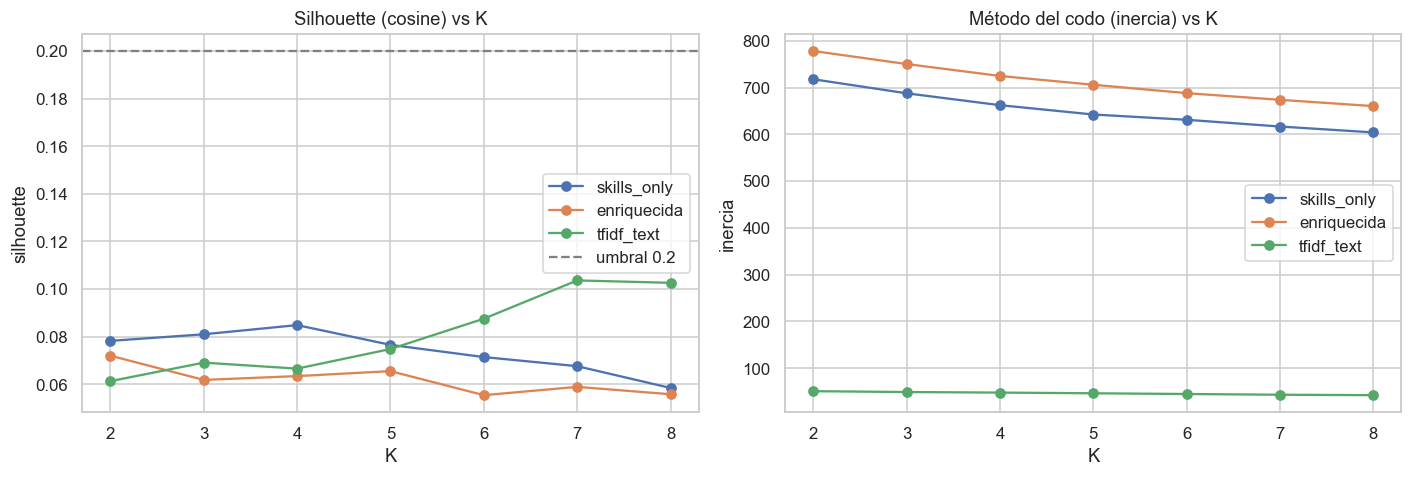

In [3]:
def select_and_cluster(X, name, krange=KRANGE, metric=METRIC, seed=RANDOM_STATE):
    Xd = np.asarray(X, dtype=float)
    ks, inertias, sils = list(krange), [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(Xd)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xd, km.labels_, metric=metric))
    best_i = int(np.argmax(sils))
    best_k = ks[best_i]
    km = KMeans(n_clusters=best_k, n_init=10, random_state=seed).fit(Xd)
    pca = PCA(n_components=2, random_state=seed)
    coords = pca.fit_transform(Xd)
    return {
        "name": name, "n_features": Xd.shape[1], "best_k": best_k,
        "silhouette": round(float(sils[best_i]), 3), "labels": km.labels_,
        "coords": coords, "pca_var": pca.explained_variance_ratio_,
        "ks": ks, "inertias": inertias, "sils": sils,
    }

results = {name: select_and_cluster(X, name) for name, X in REPS.items()}

# Varianza explicada por la proyección PCA 2D de cada representación (para citar en la memoria)
print("Varianza explicada por la proyección PCA 2D:")
for name, r in results.items():
    pc1, pc2 = r["pca_var"][0] * 100, r["pca_var"][1] * 100
    print(f"  {name:12s}: PC1={pc1:.2f}%  PC2={pc2:.2f}%  (total 2D={pc1+pc2:.1f}%)")

# Curvas de silhouette y codo (las 3 superpuestas)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, r in results.items():
    axes[0].plot(r["ks"], r["sils"], "o-", label=name)
    axes[1].plot(r["ks"], r["inertias"], "o-", label=name)
axes[0].axhline(0.2, ls="--", color="grey", label="umbral 0.2")
axes[0].set_title(f"Silhouette ({METRIC}) vs K"); axes[0].set_xlabel("K"); axes[0].set_ylabel("silhouette"); axes[0].legend()
axes[1].set_title("Método del codo (inercia) vs K"); axes[1].set_xlabel("K"); axes[1].set_ylabel("inercia"); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / "02_seleccion_k_3reps.png", bbox_inches="tight"); plt.show()

## 3. Tabla comparativa y elección de la representación principal

In [4]:
comp = pd.DataFrame([
    {"representacion": r["name"], "n_features": r["n_features"],
     "K_elegido": r["best_k"], f"silhouette_{METRIC}": r["silhouette"]}
    for r in results.values()
]).sort_values(f"silhouette_{METRIC}", ascending=False).reset_index(drop=True)

principal = comp.iloc[0]["representacion"]
print(comp.to_string(index=False))
print(f"\nMÉTRICA DEL SILHOUETTE: {METRIC} (idéntica en las 3 representaciones)")
print(f"REPRESENTACIÓN PRINCIPAL (mejor silhouette): {principal}")
comp.to_csv(CLEAN / "model1_representaciones_comparativa.csv", index=False, encoding="utf-8-sig")

representacion  n_features  K_elegido  silhouette_cosine
    tfidf_text          50          7              0.104
   skills_only          32          4              0.085
   enriquecida          36          2              0.072

MÉTRICA DEL SILHOUETTE: cosine (idéntica en las 3 representaciones)
REPRESENTACIÓN PRINCIPAL (mejor silhouette): tfidf_text


## 4. Proyección PCA 2D de las tres representaciones

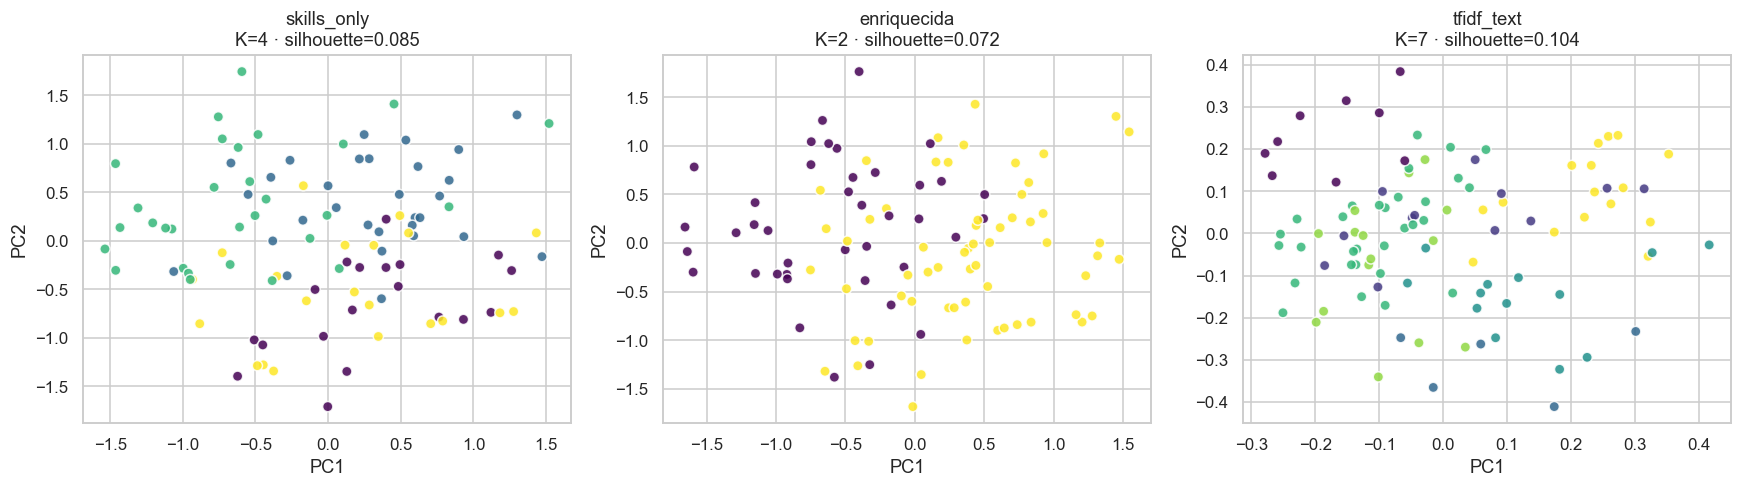

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, r) in zip(axes, results.items()):
    sc = ax.scatter(r["coords"][:, 0], r["coords"][:, 1], c=r["labels"], cmap="viridis",
                    s=45, alpha=0.85, edgecolor="white")
    ax.set_title(f"{name}\nK={r['best_k']} · silhouette={r['silhouette']}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.savefig(FIG / "02_pca_3reps.png", bbox_inches="tight"); plt.show()

## 5. Representación principal: tamaños e interpretación de clusters

In [6]:
r = results[principal]
labels = r["labels"]
sizes = pd.Series(labels, index=master_ids).value_counts().sort_index()
print(f"Representación principal: {principal} | K={r['best_k']} | silhouette ({METRIC})={r['silhouette']}")
print("\nTamaño de cada cluster:")
print(sizes.to_string())

# Interpretamos SIEMPRE describiendo cada cluster por las skills de sus miembros (R1 binaria),
# sea cual sea la representación principal.
Xb_df = pd.DataFrame(R1, index=master_ids, columns=skill_names)
global_prev = Xb_df.mean(axis=0)
print("\nSkills distintivas por cluster (prevalencia intra-cluster · lift):")
for c in sorted(np.unique(labels)):
    members = Xb_df[labels == c]
    prev = members.mean(axis=0)
    lift = (prev / global_prev.replace(0, np.nan)).fillna(0)
    score = (prev * lift).sort_values(ascending=False)
    top = score.head(8).index.tolist()
    print(f"  Cluster {c} (n={int(sizes.get(c,0))}): {', '.join(top)}")

# Guardado de asignaciones (las 3 + principal) para trazabilidad
out = pd.DataFrame({"candidate_id": master_ids})
for name, rr in results.items():
    out[f"cluster_{name}"] = rr["labels"]
out["cluster_principal"] = results[principal]["labels"]
out.attrs["principal"] = principal
out.to_csv(CLEAN / "candidate_clusters.csv", index=False, encoding="utf-8-sig")
print("\nAsignaciones guardadas en data/clean/candidate_clusters.csv (incluye las 3 representaciones).")

Representación principal: tfidf_text | K=7 | silhouette (cosine)=0.104

Tamaño de cada cluster:
0     9
1    12
2     5
3    13
4    30
5    15
6    16

Skills distintivas por cluster (prevalencia intra-cluster · lift):
  Cluster 0 (n=9): r, numpy, pandas, excel avanzado, spark, liderazgo, tableau, atención al detalle
  Cluster 1 (n=12): etl, capacidad analítica, excel avanzado, numpy, docker, orientación a resultados, data warehouse, proactividad
  Cluster 2 (n=5): azure data factory, airflow, machine learning, atención al detalle, gestión del tiempo, python, spark, sql
  Cluster 3 (n=13): liderazgo, data warehouse, comunicación, spark, git, airflow, tableau, machine learning
  Cluster 4 (n=30): resolución de problemas, sql, python, gestión del tiempo, atención al detalle, liderazgo, trabajo en equipo, storytelling con datos
  Cluster 5 (n=15): numpy, google bigquery, orientación a resultados, adaptabilidad, docker, scikit-learn, excel avanzado, git
  Cluster 6 (n=16): python, adaptab

In [7]:
# Lectura honesta del resultado de la representación principal
sil = results[principal]["silhouette"]
if sil < 0.2:
    print(f">> silhouette={sil} (<0.2): NO hay segmentación fuerte con la representación '{principal}'.")
    print("   Resultado VÁLIDO y reportable: el talento captado es homogéneo (perfiles datos/IA muy similares,")
    print("   skills muy compartidas y muestra pequeña, n=100). No se fuerza una interpretación de clusters nítidos.")
elif sil < 0.35:
    print(f">> silhouette={sil}: segmentación DÉBIL-MODERADA con '{principal}'. Interpretar con cautela.")
else:
    print(f">> silhouette={sil}: segmentación RAZONABLE con '{principal}'.")

>> silhouette=0.104 (<0.2): NO hay segmentación fuerte con la representación 'tfidf_text'.
   Resultado VÁLIDO y reportable: el talento captado es homogéneo (perfiles datos/IA muy similares,
   skills muy compartidas y muestra pequeña, n=100). No se fuerza una interpretación de clusters nítidos.


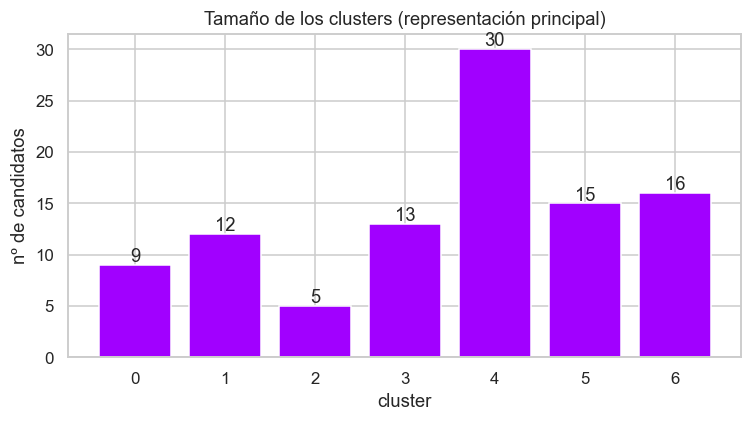

Tamaño de cada cluster (representación principal):
0     9
1    12
2     5
3    13
4    30
5    15
6    16


In [8]:
# [añadido] Tamaño de clusters de la representación principal (solo lee variables ya calculadas)
_labels = results[principal]["labels"]
_sizes = pd.Series(_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(_sizes.index.astype(str), _sizes.values, color=ACCENT)
ax.set_title("Tamaño de los clusters (representación principal)")
ax.set_xlabel("cluster"); ax.set_ylabel("nº de candidatos")
for xi, v in zip(_sizes.index.astype(str), _sizes.values):
    ax.text(xi, v + 0.3, str(v), ha="center")
plt.tight_layout(); plt.savefig(FIG / "02_tam_clusters_principal.png", bbox_inches="tight"); plt.show()

# [añadido] valores numéricos (para citar en la memoria)
print("Tamaño de cada cluster (representación principal):")
print(_sizes.to_string())

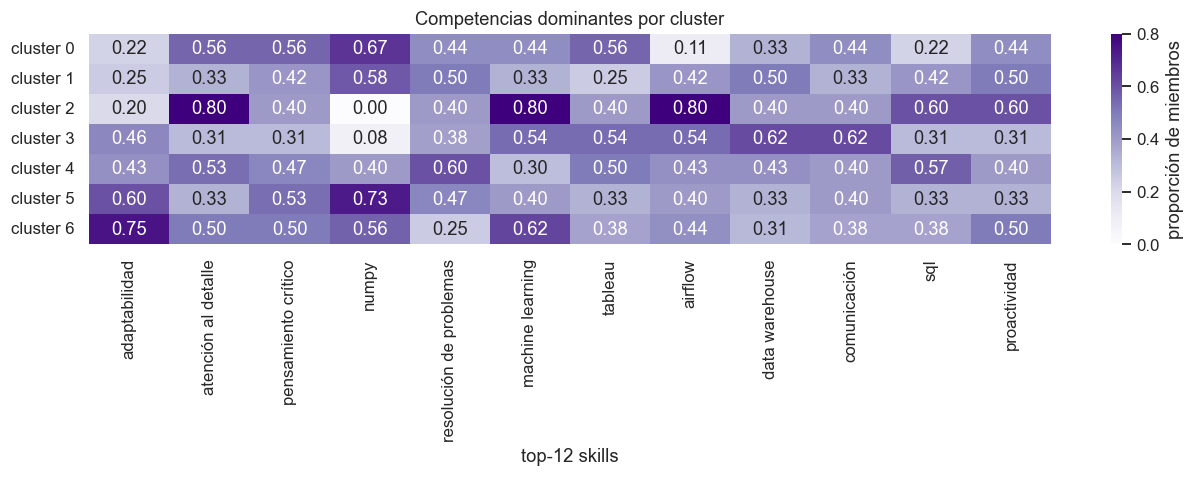

Prevalencia de las 12 competencias por cluster (proporción de miembros):
           adaptabilidad  atención al detalle  pensamiento crítico  numpy  resolución de problemas  machine learning  tableau  airflow  data warehouse  comunicación   sql  proactividad
cluster 0           0.22                 0.56                 0.56   0.67                     0.44              0.44     0.56     0.11            0.33          0.44  0.22          0.44
cluster 1           0.25                 0.33                 0.42   0.58                     0.50              0.33     0.25     0.42            0.50          0.33  0.42          0.50
cluster 2           0.20                 0.80                 0.40   0.00                     0.40              0.80     0.40     0.80            0.40          0.40  0.60          0.60
cluster 3           0.46                 0.31                 0.31   0.08                     0.38              0.54     0.54     0.54            0.62          0.62  0.31          0.31
cl

In [9]:
# [añadido] Prevalencia de las 12 skills más frecuentes por cluster (lee R1/skill_names/labels)
_labels = results[principal]["labels"]
_Xb = pd.DataFrame(R1, index=master_ids, columns=skill_names)
_top12 = _Xb.mean(axis=0).sort_values(ascending=False).head(12).index.tolist()
_idx = np.array(master_ids)
_rows, _names = [], []
for c in sorted(np.unique(_labels)):
    _rows.append(_Xb.loc[_idx[_labels == c], _top12].mean(axis=0).values)
    _names.append(f"cluster {c}")
_mat = pd.DataFrame(_rows, index=_names, columns=_top12)
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(_mat, annot=True, fmt=".2f", cmap="Purples", cbar_kws={"label": "proporción de miembros"}, ax=ax)
ax.set_title("Competencias dominantes por cluster")
ax.set_xlabel("top-12 skills"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIG / "02_skills_por_cluster.png", bbox_inches="tight"); plt.show()

# [añadido] valores numéricos (para citar en la memoria)
print("Prevalencia de las 12 competencias por cluster (proporción de miembros):")
print(_mat.round(2).to_string())

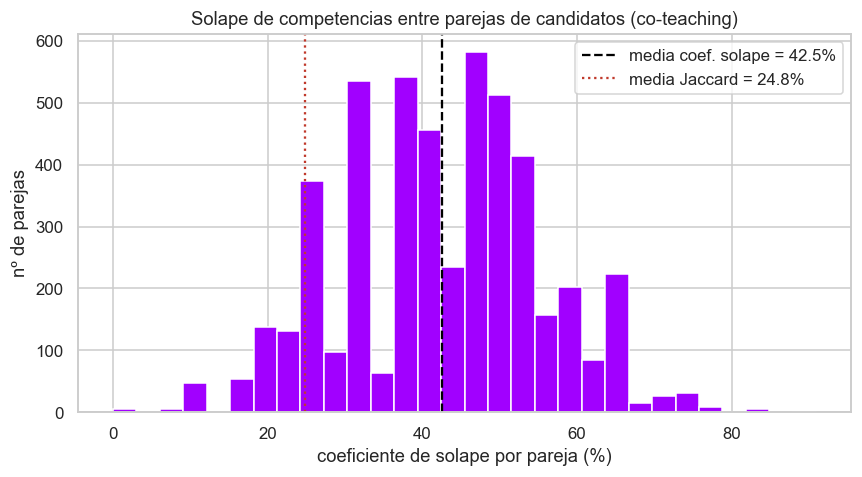

Parejas: 4950 | media coef. solape: 42.5% | media Jaccard: 24.8%


In [10]:
# [añadido] Co-teaching: solape de competencias entre TODAS las parejas de candidatos (read-only desde R1)
_S = R1.astype(bool).astype(int)
_inter = _S @ _S.T                                  # intersecciones por par
_sizes = _S.sum(axis=1)
_iu = np.triu_indices(_S.shape[0], k=1)             # 4950 pares (i<j)
_ii = _inter[_iu]
_minsz = np.minimum(_sizes[_iu[0]], _sizes[_iu[1]])
_uni = _sizes[_iu[0]] + _sizes[_iu[1]] - _ii
_overlap = _ii / np.where(_minsz == 0, 1, _minsz)   # coeficiente de solape |A∩B|/min(|A|,|B|)
_jacc = _ii / np.where(_uni == 0, 1, _uni)          # Jaccard |A∩B|/|A∪B|
_m_ov = _overlap.mean() * 100
_m_ja = _jacc.mean() * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(_overlap * 100, bins=30, color=ACCENT)
ax.axvline(_m_ov, ls="--", color="black", label=f"media coef. solape = {_m_ov:.1f}%")
ax.axvline(_m_ja, ls=":", color="#c0392b", label=f"media Jaccard = {_m_ja:.1f}%")
ax.set_title("Solape de competencias entre parejas de candidatos (co-teaching)")
ax.set_xlabel("coeficiente de solape por pareja (%)"); ax.set_ylabel("nº de parejas")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "02_coteaching_solape.png", bbox_inches="tight"); plt.show()
print(f"Parejas: {len(_overlap)} | media coef. solape: {_m_ov:.1f}% | media Jaccard: {_m_ja:.1f}%")

## 6. Hallazgos clave

- Se compararon **3 representaciones** del perfil de candidato con el **mismo protocolo** (K=2..8,
  `random_state=42`) y la **misma métrica de silhouette (coseno)**, declarada explícitamente.
- La **tabla comparativa** (sección 3) recoge nº de features, K elegido y silhouette de cada una; la
  **principal** es la de mejor silhouette (impresa arriba).
- Los valores de silhouette obtenidos son la cifra a citar en la memoria (consistente entre las tres).
  Si son bajos (<0.2) se reportan como **talento homogéneo**, no como fallo del método.
- Asignaciones de cluster (las 3 representaciones + principal) en `data/clean/candidate_clusters.csv`;
  figuras en `notebooks/figures/02_seleccion_k_3reps.png` y `02_pca_3reps.png`.

*(Los números concretos quedan impresos en las celdas tras ejecutar.)*